In [1]:
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import scipy.sparse as sp
import os 
from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots
import pandas as pd

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

from helpers import *

device: cuda


# Check phantom analysis results

## SXR 

In [12]:
# check sxr phantom analysis results
#csv_name = f"metrics_diffusion_sxr_{sigma_y_tomo}_zeta{zeta}_lambda{lambda_}.csv"

noise_levels = [0.05, 0.25, 0.5]

results = []
results_procedureTrue = []
for noise in noise_levels:
    csv_name = f"metrics_csv_phantom_analysis/metrics_diffusion_sxr_{noise}_false.csv"
    csv_name_procedureTrue = f"metrics_csv_phantom_analysis/metrics_diffusion_sxr_{noise}_true.csv"
    if os.path.exists(csv_name):
        df = pd.read_csv(csv_name)
        df["noise"] = noise
        results.append(df)
    if os.path.exists(csv_name_procedureTrue):
        df = pd.read_csv(csv_name_procedureTrue)
        df["noise"] = noise
        results_procedureTrue.append(df)
    else:
        print(f"File {csv_name} not found.")

# Average metrics for the first noise-level entry (0.05)

for i in range(len(results)):
    print(f"Noise level: {results[i]['noise'].iloc[0]}")

    df_noise = results[i]  # corresponds to the current noise level

    metrics = ["mse", "ssim", "psnr"]
    metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

print('\n')

for i in range(len(results_procedureTrue)):
    print(f"Noise level: {results_procedureTrue[i]['noise'].iloc[0]}, procedure=True")

    df_noise = results_procedureTrue[i]  # corresponds to the current noise level

    metrics = ["mse", "ssim", "psnr"]
    metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")


Noise level: 0.05
MSE: 0.000026 +- 0.0001
SSIM: 0.996104 +- 0.0074
PSNR: 47.074031 +- 3.1666
Noise level: 0.25
MSE: 0.000124 +- 0.0001
SSIM: 0.985892 +- 0.0110
PSNR: 40.046038 +- 3.1298
Noise level: 0.5
MSE: 0.000312 +- 0.0002
SSIM: 0.971575 +- 0.0176
PSNR: 35.997982 +- 3.1973


Noise level: 0.05, procedure=True
MSE: 95.763879 +- 247.5900
SSIM: 0.981761 +- 0.0281
PSNR: 40.836958 +- 7.1251
Noise level: 0.25, procedure=True
MSE: 149.169221 +- 304.4846
SSIM: 0.970827 +- 0.0303
PSNR: 36.418206 +- 5.0711
Noise level: 0.5, procedure=True
MSE: 218.593167 +- 367.4471
SSIM: 0.956487 +- 0.0341
PSNR: 33.644113 +- 4.0949


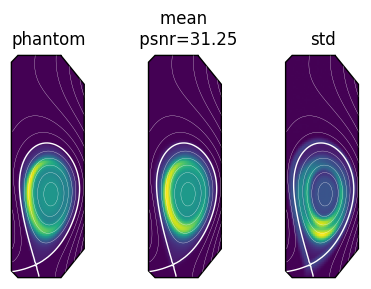

In [11]:
H, W = 120, 40

idx_to_be_plotted = 0
noise_idx=2
noise_=str(noise_levels[noise_idx])
res=results[noise_idx]
means,stds = np.load("metrics_csv_phantom_analysis/post_means_sxr_" + noise_ + "_false.npy")[idx_to_be_plotted,:], np.load("metrics_csv_phantom_analysis/post_stds_sxr_" + noise_ + "_false.npy")[idx_to_be_plotted,:]

samples_dir  = Path("/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples")
ground_truth = np.load(samples_dir / "sxr_samples_with_background_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
psi         = np.load(samples_dir / "psis_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)

# plot using show_samples
summary = torch.stack([
        torch.from_numpy(ground_truth).view(1,1,H,W),
        torch.from_numpy(means).view(1,1,H,W),
        torch.from_numpy(stds).view(1,1,H,W)
])
show_samples(summary, titles=["phantom",
                              "mean \n psnr={:.2f}".format(res['psnr'][idx_to_be_plotted]),
                              "std"], contour_images=[psi,psi,psi])

## DMPX

In [13]:
# check sxr phantom analysis results
#csv_name = f"metrics_diffusion_sxr_{sigma_y_tomo}_zeta{zeta}_lambda{lambda_}.csv"

noise_levels = [0.1, 0.5, 1.0]

results = []
results_procedureTrue = []
for noise in noise_levels:
    csv_name = f"metrics_csv_phantom_analysis/metrics_diffusion_dmpx_{noise}_false.csv"
    csv_name_procedureTrue = f"metrics_csv_phantom_analysis/metrics_diffusion_dmpx_{noise}_true.csv"
    if os.path.exists(csv_name):
        df = pd.read_csv(csv_name)
        df["noise"] = noise
        results.append(df)
    if os.path.exists(csv_name_procedureTrue):
        df = pd.read_csv(csv_name_procedureTrue)
        df["noise"] = noise
        results_procedureTrue.append(df)
    else:
        print(f"File {csv_name} not found.")

# Average metrics for the first noise-level entry (0.05)

for i in range(len(results)):
    print(f"Noise level: {results[i]['noise'].iloc[0]}")

    df_noise = results[i]  # corresponds to the current noise level

    metrics = ["mse", "ssim", "psnr"]
    metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

print('\n')

for i in range(len(results_procedureTrue)):
    print(f"Noise level: {results_procedureTrue[i]['noise'].iloc[0]}, procedure=True")

    df_noise = results_procedureTrue[i]  # corresponds to the current noise level

    metrics = ["mse", "ssim", "psnr"]
    metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")


Noise level: 0.1
MSE: 0.000140 +- 0.0002
SSIM: 0.985921 +- 0.0133
PSNR: 41.552544 +- 5.2016
Noise level: 0.5
MSE: 0.000313 +- 0.0004
SSIM: 0.968405 +- 0.0228
PSNR: 37.330657 +- 4.6776
Noise level: 1.0
MSE: 0.000519 +- 0.0005
SSIM: 0.950079 +- 0.0297
PSNR: 34.612533 +- 4.2124


Noise level: 0.1, procedure=True
MSE: 185.582995 +- 417.6733
SSIM: 0.961540 +- 0.0411
PSNR: 36.037321 +- 6.3403
Noise level: 0.5, procedure=True
MSE: 266.889396 +- 537.4116
SSIM: 0.943303 +- 0.0470
PSNR: 33.493747 +- 5.3089
Noise level: 1.0, procedure=True
MSE: 332.750098 +- 603.4561
SSIM: 0.927450 +- 0.0496
PSNR: 31.911206 +- 4.6735


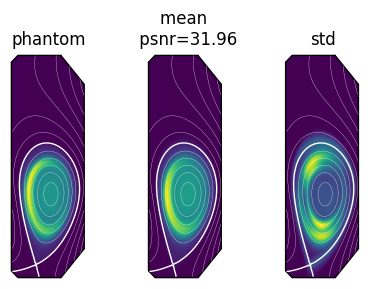

In [ ]:
H, W = 120, 40

idx_to_be_plotted = 0
noise_idx=0
noise_=str(noise_levels[noise_idx])
res=results[noise_idx]
means,stds = np.load("metrics_csv_phantom_analysis/post_means_dmpx_" + noise_ + "_false.npy")[idx_to_be_plotted,:], np.load("metrics_csv_phantom_analysis/post_stds_dmpx_" + noise_ + "_false.npy")[idx_to_be_plotted,:]

samples_dir  = Path("/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples")
ground_truth = np.load(samples_dir / "sxr_samples_with_background_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
psi         = np.load(samples_dir / "psis_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)

# plot using show_samples
summary = torch.stack([
        torch.from_numpy(ground_truth).view(1,1,H,W),
        torch.from_numpy(means).view(1,1,H,W),
        torch.from_numpy(stds).view(1,1,H,W)
])
show_samples(summary, titles=["phantom",
                              "mean \n psnr={:.2f}".format(res['psnr'][idx_to_be_plotted]),
                              "std"], contour_images=[psi,psi,psi])

## Pilatus, clip=False

In [23]:
noise_levels = [0.05, 0.25, 0.5]

results = []
results_procedureTrue = []
for noise in noise_levels:
    csv_name = f"metrics_csv_phantom_analysis/metrics_diffusion_pilatus_{noise}_clipFalse_false.csv"
    csv_name_procedureTrue = f"metrics_csv_phantom_analysis/metrics_diffusion_pilatus_{noise}_clipFalse_true.csv"
    if os.path.exists(csv_name):
        df = pd.read_csv(csv_name)
        df["noise"] = noise
        results.append(df)
    if os.path.exists(csv_name_procedureTrue):
        df = pd.read_csv(csv_name_procedureTrue)
        df["noise"] = noise
        results_procedureTrue.append(df)
    else:
        print(f"File {csv_name} not found.")

# Average metrics for the first noise-level entry (0.05)

for i in range(len(results)):
    print(f"Noise level: {results[i]['noise'].iloc[0]}")

    df_noise = results[i]  # corresponds to the current noise level

    metrics = ["mse", "ssim", "psnr"]
    metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

print('\n')

for i in range(len(results_procedureTrue)):
    print(f"Noise level: {results_procedureTrue[i]['noise'].iloc[0]}, procedure=True")

    df_noise = results_procedureTrue[i]  # corresponds to the current noise level

    metrics = ["mse", "ssim", "psnr"]
    metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        valid = df_noise[m].replace([np.inf, -np.inf], np.nan).dropna()
        n_excluded = len(df_noise) - len(valid)
        if n_excluded > 0:
            print(f"  [{m}] Excluded {n_excluded} Inf value(s)")
        print(f"{metric_labels[m]}: {valid.mean():.6f} +- {valid.std():.4f}")

Noise level: 0.05
MSE: 0.007707 +- 0.0069
SSIM: 0.748029 +- 0.1002
PSNR: 22.463075 +- 3.6851
Noise level: 0.25
MSE: 0.007969 +- 0.0070
SSIM: 0.737318 +- 0.0992
PSNR: 22.242948 +- 3.5639
Noise level: 0.5
MSE: 0.008192 +- 0.0071
SSIM: 0.728675 +- 0.0988
PSNR: 22.078659 +- 3.4900


Noise level: 0.05, procedure=True
MSE: 2544.468926 +- 3728.1732
SSIM: 0.739125 +- 0.0979
PSNR: 22.152248 +- 3.5980
Noise level: 0.25, procedure=True
MSE: 2618.807413 +- 3756.2762
SSIM: 0.727448 +- 0.0975
PSNR: 21.925866 +- 3.5255
Noise level: 0.5, procedure=True
MSE: 2704.678551 +- 3833.4920
SSIM: 0.719203 +- 0.0980
PSNR: 21.784524 +- 3.4878


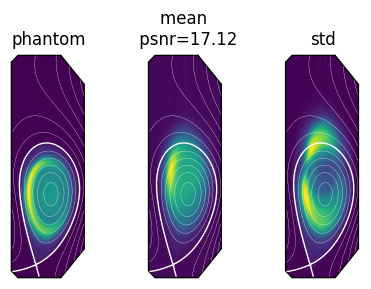

In [28]:
H, W = 120, 40

idx_to_be_plotted = 0
noise_idx=0
noise_=str(noise_levels[noise_idx])
res=results[noise_idx]
means,stds = np.load("metrics_csv_phantom_analysis/post_means_pilatus_" + noise_ + "_clipFalse_false.npy")[idx_to_be_plotted,:], \
                        np.load("metrics_csv_phantom_analysis/post_stds_pilatus_" + noise_ + "_clipFalse_false.npy")[idx_to_be_plotted,:]

samples_dir  = Path("/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples")
ground_truth = np.load(samples_dir / "sxr_samples_with_background_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
psi         = np.load(samples_dir / "psis_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)

# plot using show_samples
summary = torch.stack([
        torch.from_numpy(ground_truth).view(1,1,H,W),
        torch.from_numpy(means).view(1,1,H,W),
        torch.from_numpy(stds).view(1,1,H,W)
])
show_samples(summary, titles=["phantom",
                              "mean \n psnr={:.2f}".format(res['psnr'][idx_to_be_plotted]),
                              "std"], contour_images=[psi,psi,psi])

## Pilatus, clip=True

In [29]:
noise_levels = [0.05, 0.25, 0.5]

results = []
results_procedureTrue = []
for noise in noise_levels:
    csv_name = f"metrics_csv_phantom_analysis/metrics_diffusion_pilatus_{noise}_clipTrue_false.csv"
    csv_name_procedureTrue = f"metrics_csv_phantom_analysis/metrics_diffusion_pilatus_{noise}_clipTrue_true.csv"
    if os.path.exists(csv_name):
        df = pd.read_csv(csv_name)
        df["noise"] = noise
        results.append(df)
    if os.path.exists(csv_name_procedureTrue):
        df = pd.read_csv(csv_name_procedureTrue)
        df["noise"] = noise
        results_procedureTrue.append(df)
    else:
        print(f"File {csv_name} not found.")

# Average metrics for the first noise-level entry (0.05)

for i in range(len(results)):
    print(f"Noise level: {results[i]['noise'].iloc[0]}")

    df_noise = results[i]  # corresponds to the current noise level

    metrics = ["mse", "ssim", "psnr"]
    metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

print('\n')

for i in range(len(results_procedureTrue)):
    print(f"Noise level: {results_procedureTrue[i]['noise'].iloc[0]}, procedure=True")

    df_noise = results_procedureTrue[i]  # corresponds to the current noise level

    metrics = ["mse", "ssim", "psnr"]
    metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        valid = df_noise[m].replace([np.inf, -np.inf], np.nan).dropna()
        n_excluded = len(df_noise) - len(valid)
        if n_excluded > 0:
            print(f"  [{m}] Excluded {n_excluded} Inf value(s)")
        print(f"{metric_labels[m]}: {valid.mean():.6f} +- {valid.std():.4f}")

Noise level: 0.05
MSE: 0.002395 +- 0.0034
SSIM: 0.914484 +- 0.0619
PSNR: 29.002218 +- 5.0992
Noise level: 0.25
MSE: 0.002508 +- 0.0033
SSIM: 0.906884 +- 0.0625
PSNR: 28.569908 +- 4.8916
Noise level: 0.5
MSE: 0.002676 +- 0.0034
SSIM: 0.898714 +- 0.0645
PSNR: 28.063343 +- 4.6788


Noise level: 0.05, procedure=True
  [mse] Excluded 7 Inf value(s)
MSE: 6424627528941382844620757532672.000000 +- 180224443871180634216175044132864.0000
  [ssim] Excluded 7 Inf value(s)
SSIM: 0.878542 +- 0.1382
  [psnr] Excluded 7 Inf value(s)
PSNR: 19.466174 +- 39.6168
Noise level: 0.25, procedure=True
MSE: 992.748775 +- 1747.3379
SSIM: 0.896942 +- 0.0640
PSNR: 27.198190 +- 4.3873
Noise level: 0.5, procedure=True
MSE: 1068.766107 +- 1851.3834
SSIM: 0.889604 +- 0.0645
PSNR: 26.808877 +- 4.2097


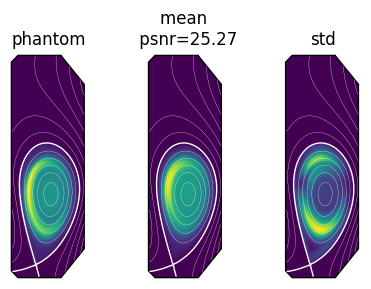

In [30]:
H, W = 120, 40

idx_to_be_plotted = 0
noise_idx=0
noise_=str(noise_levels[noise_idx])
res=results[noise_idx]
means,stds = np.load("metrics_csv_phantom_analysis/post_means_pilatus_" + noise_ + "_clipTrue_false.npy")[idx_to_be_plotted,:], \
                        np.load("metrics_csv_phantom_analysis/post_stds_pilatus_" + noise_ + "_clipTrue_false.npy")[idx_to_be_plotted,:]

samples_dir  = Path("/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples")
ground_truth = np.load(samples_dir / "sxr_samples_with_background_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
psi         = np.load(samples_dir / "psis_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)

# plot using show_samples
summary = torch.stack([
        torch.from_numpy(ground_truth).view(1,1,H,W),
        torch.from_numpy(means).view(1,1,H,W),
        torch.from_numpy(stds).view(1,1,H,W)
])
show_samples(summary, titles=["phantom",
                              "mean \n psnr={:.2f}".format(res['psnr'][idx_to_be_plotted]),
                              "std"], contour_images=[psi,psi,psi])